<a href="https://colab.research.google.com/github/Snehadas2005/Python-And-AI-Training/blob/main/Final_LLM_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install textblob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
# Load dataset
df = pd.read_csv('test.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Display initial dataset structure
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Subject  2191 non-null   object        
 1   body     2191 non-null   object        
 2   date     2191 non-null   datetime64[ns]
 3   from     2191 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 68.6+ KB


,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",2010-07-29,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com


# Step 3: Task 1 – Sentiment Labeling using TextBlob
This assigns sentiment polarity and adds the required `Positive`, `Negative`, or `Neutral` label to each message.

In [5]:
# Function to classify sentiment using TextBlob
def get_sentiment(text):
    if pd.isna(text):
        return 'Neutral'
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0.05:
        return 'Positive'
    elif analysis.sentiment.polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Assign sentiment labels and numerical scores using the 'body' column
df['sentiment'] = df['body'].apply(get_sentiment)

# Numeric mapping: Positive = +1, Negative = -1, Neutral = 0
sentiment_map = {'Positive': 1, 'Negative': -1, 'Neutral': 0}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Display first few rows
df[['from', 'body', 'sentiment', 'sentiment_score']].head()

,from,body,sentiment,sentiment_score
0,sally.beck@enron.com,EnronOptions Announcement\n\n\nWe have updated...,Positive,1
1,eric.bass@enron.com,"Marc,\n\nUnfortunately, today is not going to ...",Negative,-1
2,sally.beck@enron.com,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",Neutral,0
3,johnny.palmer@enron.com,we were thinking papasitos (we can meet somewh...,Negative,-1
4,lydia.delgado@enron.com,Since you never gave me the $20 for the last t...,Neutral,0


# Step 4: Task 2 – Exploratory Data Analysis (EDA)
Generate required visualizations and check for missing values or overall distributions.

Missing Values Summary:
 Subject            0
body               0
date               0
from               0
sentiment          0
sentiment_score    0
dtype: int64


/tmp/ipykernel_2865/2995770023.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


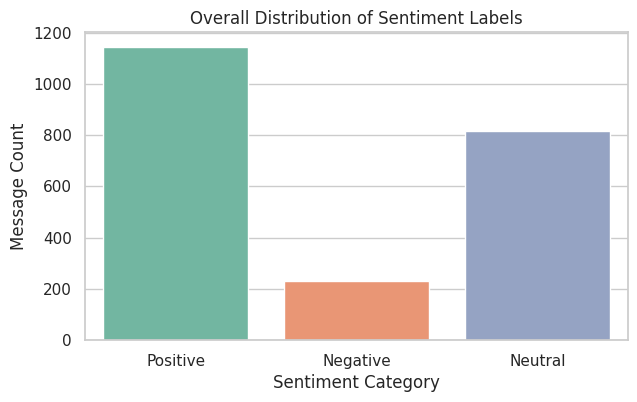

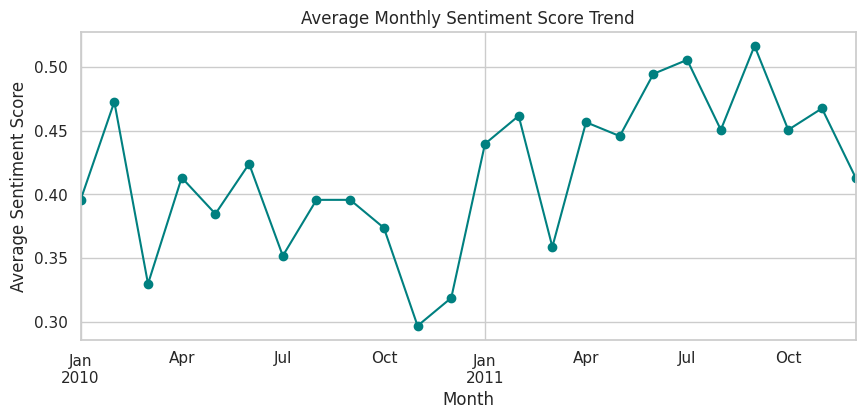

In [6]:
# 1. Missing values check
print("Missing Values Summary:\n", df.isnull().sum())

# 2. Plot overall sentiment distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Overall Distribution of Sentiment Labels')
plt.xlabel('Sentiment Category')
plt.ylabel('Message Count')
plt.show()

# 3. Monthly Sentiment Trend Visualization
df['year_month'] = df['date'].dt.to_period('M')
monthly_trend = df.groupby('year_month')['sentiment_score'].mean()

plt.figure(figsize=(10, 4))
monthly_trend.plot(kind='line', marker='o', color='teal')
plt.title('Average Monthly Sentiment Score Trend')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()

# Step 5: Tasks 3 & 4 – Monthly Scoring, Employee Ranking & Flight Risk Identification
Aggregate scores monthly per employee and flag flight risk candidates (4+ negative messages in a single month).

In [8]:
# Aggregate monthly sentiment scores per employee using the 'from' column
monthly_emp_stats = df.groupby(['year_month', 'from']).agg(
    total_score=('sentiment_score', 'sum'),
    negative_count=('sentiment', lambda x: (x == 'Negative').sum()),
    message_count=('sentiment', 'count')
).reset_index()

# Task 4: Flight Risk Identification (4 or more negative messages in a month)
monthly_emp_stats['flight_risk'] = monthly_emp_stats['negative_count'] >= 4

# Task 4: Employee Ranking per month by total score
monthly_emp_stats['rank'] = monthly_emp_stats.groupby('year_month')['total_score'].rank(ascending=False, method='min')

# Display Flight Risk employees
flight_risks = monthly_emp_stats[monthly_emp_stats['flight_risk'] == True]
print(f"Total Flight Risk Occurrences: {len(flight_risks)}")
flight_risks.head()

Total Flight Risk Occurrences: 9


,year_month,from,total_score,negative_count,message_count,flight_risk,rank
14,2010-02,johnny.palmer@enron.com,6,4,18,True,3.0
53,2010-06,john.arnold@enron.com,3,5,15,True,5.0
69,2010-07,sally.beck@enron.com,-1,5,14,True,9.0
82,2010-09,eric.bass@enron.com,2,4,15,True,8.0
100,2010-11,bobette.riner@ipgdirect.com,2,5,16,True,7.0


# Step 6: Task 5 – Predictive Modeling (Linear Regression)
Build a Linear Regression model predicting average monthly sentiment trends.

In [9]:
# Prepare data for modeling
monthly_summary = df.groupby('year_month').agg(
    avg_score=('sentiment_score', 'mean'),
    msg_count=('sentiment_score', 'count')
).reset_index()

# Convert time index to ordinal integer sequence for regression
monthly_summary['month_index'] = np.arange(len(monthly_summary))

X = monthly_summary[['month_index', 'msg_count']]
y = monthly_summary['avg_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate predictions
y_pred = model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Model Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")

Model R2 Score: 0.2578
Model Mean Squared Error (MSE): 0.0028


In [11]:
# Save final datasets
df.to_csv('processed_sentiment_data.csv', index=False)
monthly_emp_stats.to_csv('monthly_employee_rankings.csv', index=False)

from google.colab import files
files.download('processed_sentiment_data.csv')
files.download('monthly_employee_rankings.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>